### 기본 설정 및 준비

In [1]:
# ============================================================
# [CELL 0] 패키지 설치
# - 이 노트북은 start_RAG.ipynb의 기본 흐름을 확장한 버전입니다.
# - OpenAI + LangChain + Chroma + RAGAS 기반으로 구성합니다.
# - retriever 관련 일부 모듈은 최근 버전에서 langchain-classic으로 분리되어
#   있으므로 함께 설치합니다.
# - reranker / hybrid retrieval / ragas 평가까지 한 번에 사용할 수 있도록
#   필요한 패키지를 미리 설치합니다.
# ============================================================

# !pip install -U langchain langchain-core langchain-community langchain-openai
# !pip install -U langchain-text-splitters langchain-experimental langchain-classic
# !pip install -U chromadb pypdf python-dotenv tiktoken
# !pip install -U rank-bm25 sentence-transformers datasets ragas
# !pip install -U langchain-experimental
# !pip install sentence-transformers
# !pip install ragas==0.1.21 --force-reinstall

In [1]:
# ============================================================
# [CELL 1] 환경변수 로드 및 공통 설정
# - start_RAG.ipynb에서 하던 dotenv 로딩 방식을 그대로 사용합니다.
# - Gemini는 제외하고 OpenAI만 사용합니다.
# - 아래 DOCUMENT_PATH만 바꾸면 PDF / TXT / CSV 중심으로 실험할 수 있게 구성합니다.
# - COLLECTION_PREFIX는 Chroma 컬렉션 이름 충돌을 피하기 위해 사용합니다.
# ============================================================

from dotenv import load_dotenv
import os
import uuid

# 본인 환경에 맞게 수정
load_dotenv(r"D:\PyProject\env_keys\.env")

openai_key = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = openai_key

# -----------------------------
# 실험 대상 문서 경로
# 예시:
# DOCUMENT_PATH = "./data/Demian.pdf"
# DOCUMENT_PATH = "./data/state_of_the_union.txt"
# DOCUMENT_PATH = "./data/titanic.csv"
# -----------------------------
DOCUMENT_PATH = "./data/Demian.pdf"

# Chroma collection 이름 충돌 방지용 prefix
COLLECTION_PREFIX = "start_rag_upgrade"

# 기본 chunk 설정
DEFAULT_CHUNK_SIZE = 500
DEFAULT_CHUNK_OVERLAP = 50

# 검색 기본값
TOP_K = 4
FETCH_K = 12

print("OPENAI_API_KEY loaded:", bool(openai_key))
print("DOCUMENT_PATH:", DOCUMENT_PATH)

OPENAI_API_KEY loaded: True
DOCUMENT_PATH: ./data/Demian.pdf


In [3]:
# ============================================================
# [CELL 2] 공통 import 및 LLM / Embedding 준비
# - start_RAG의 핵심 구성요소(Loader -> Splitter -> Embedding -> VectorStore -> Retriever)를
#   유지하면서, 이후 단계별 기법을 쉽게 꽂을 수 있도록 공통 모듈을 한 번에 준비합니다.
# - answer 생성은 ChatOpenAI(gpt-4o-mini), 임베딩은 text-embedding-3-small 기준입니다.
# ============================================================

import re
import json
import math
import textwrap
from pathlib import Path
from typing import List, Dict, Any, Callable

from langchain_core.documents import Document
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

from langchain_community.document_loaders import (
    PyPDFLoader,
    TextLoader,
    CSVLoader,
)

from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Semantic chunking
from langchain_experimental.text_splitter import SemanticChunker

# Advanced retrievers
from langchain_classic.retrievers.multi_query import MultiQueryRetriever
from langchain_classic.retrievers import ContextualCompressionRetriever, EnsembleRetriever

# BM25:Best Matching 알고리즘 25번 버전
# 정보 검색(IR)에서 가장 유명한 랭킹 알고리즘 중 하나 Best Matching, BM25는 단순 TF-IDF보다 발전된 형태로
from langchain_community.retrievers import BM25Retriever

# Reranker
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# Evaluation
import pandas as pd
from datasets import Dataset

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    api_key=openai_key
)

embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_key
)

print("LLM / Embedding 준비 완료")

LLM / Embedding 준비 완료


In [4]:
# ============================================================
# [CELL 3] 공통 유틸리티 함수
# - 이 셀은 이후 모든 단계에서 공통으로 재사용할 helper 모음입니다.
# - 주요 역할:
#   1) 문서 로딩
#   2) 메타데이터 강화
#   3) vectorstore 생성
#   4) 문서들을 context 문자열로 묶기
#   5) retriever 결과를 바탕으로 최종 답변 생성
# - 즉, 이후 단계는 "retriever만 바꿔 끼우는" 방식으로 비교하기 쉽게 설계합니다.
# ============================================================

def detect_file_type(path: str) -> str:
    ext = Path(path).suffix.lower()
    return ext.replace(".", "")

def load_documents(path: str) -> List[Document]:
    ext = Path(path).suffix.lower()

    if ext == ".pdf":
        loader = PyPDFLoader(path)
        docs = loader.load()
    elif ext in [".txt", ".md"]:
        loader = TextLoader(path, encoding="utf-8")
        docs = loader.load()
    elif ext == ".csv":
        loader = CSVLoader(path, encoding="utf-8")
        docs = loader.load()
    else:
        raise ValueError(f"지원하지 않는 파일 형식입니다: {ext}")

    return docs

def simple_keywords(text: str, top_n: int = 8) -> List[str]:
    tokens = re.findall(r"[가-힣A-Za-z0-9]{2,}", text.lower())
    stop = {
        "그리고", "그러나", "하지만", "입니다", "있는", "하는", "대한", "에서",
        "with", "that", "this", "from", "have", "were", "what", "when", "where",
        "which", "shall", "into", "also", "their", "there", "about"
    }
    freq = {}
    for t in tokens:
        if t not in stop:
            freq[t] = freq.get(t, 0) + 1
    return [k for k, _ in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:top_n]]

def guess_section_title(text: str) -> str:
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if not lines:
        return "unknown"
    first = lines[0]
    return first[:80]

def enrich_metadata(
    docs: List[Document],
    source_path: str
) -> List[Document]:
    file_type = detect_file_type(source_path)
    file_name = Path(source_path).name

    enriched = []
    for i, doc in enumerate(docs):
        text = doc.page_content or ""
        meta = dict(doc.metadata) if doc.metadata else {}

        meta["source_path"] = source_path
        meta["source_file"] = file_name
        meta["file_type"] = file_type
        meta["doc_id"] = i
        meta["section_title"] = guess_section_title(text)
        meta["keywords"] = simple_keywords(text, top_n=8)

        # PDF라면 page 메타데이터가 들어있는 경우가 많으므로 보정
        if "page" in meta:
            meta["page_num"] = meta["page"]

        enriched.append(Document(page_content=text, metadata=meta))

    return enriched

def make_recursive_chunks(
    docs: List[Document],
    chunk_size: int = DEFAULT_CHUNK_SIZE,
    chunk_overlap: int = DEFAULT_CHUNK_OVERLAP
) -> List[Document]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    split_docs = splitter.split_documents(docs)

    for idx, d in enumerate(split_docs):
        d.metadata["chunk_id"] = idx
        d.metadata["chunking"] = "recursive"

    return split_docs

def make_semantic_chunks(docs: List[Document]) -> List[Document]:
    # SemanticChunker는 문맥 전환 지점을 기준으로 잘라서
    # 단순 고정 길이 split보다 의미 단위가 잘 보존되도록 합니다.
    all_text = "\n\n".join([d.page_content for d in docs if d.page_content.strip()])

    splitter = SemanticChunker(
        embeddings=embedding_model,
        breakpoint_threshold_type="percentile"
    )
    split_docs = splitter.create_documents([all_text])

    for idx, d in enumerate(split_docs):
        d.metadata["chunk_id"] = idx
        d.metadata["chunking"] = "semantic"
        d.metadata["source_path"] = docs[0].metadata.get("source_path", DOCUMENT_PATH)
        d.metadata["source_file"] = docs[0].metadata.get("source_file", Path(DOCUMENT_PATH).name)
        d.metadata["file_type"] = docs[0].metadata.get("file_type", detect_file_type(DOCUMENT_PATH))

    return split_docs

def build_chroma(
    docs: List[Document],
    collection_name: str
):
    return Chroma.from_documents(
        documents=docs,
        embedding=embedding_model,
        collection_name=f"{COLLECTION_PREFIX}_{collection_name}_{uuid.uuid4().hex[:8]}"
    )

def docs_to_context(docs: List[Document]) -> str:
    blocks = []
    for i, d in enumerate(docs, start=1):
        meta = d.metadata or {}
        head = {
            "idx": i,
            "source_file": meta.get("source_file"),
            "page_num": meta.get("page_num"),
            "section_title": meta.get("section_title"),
            "file_type": meta.get("file_type"),
            "chunk_id": meta.get("chunk_id"),
        }
        blocks.append(
            f"[문서 {i} | 메타데이터] {json.dumps(head, ensure_ascii=False)}\n"
            f"{d.page_content}"
        )
    return "\n\n" + ("\n\n" + "=" * 70 + "\n\n").join(blocks)

def answer_with_docs(question: str, docs: List[Document], system_name: str = "RAG") -> Dict[str, Any]:
    context = docs_to_context(docs)

    prompt = f"""
당신은 문서기반 질의응답 도우미입니다.
반드시 제공된 문서 내용에 근거해서만 답하세요.
문서에 없는 내용은 추측하지 말고 "문서에서 확인되지 않습니다."라고 말하세요.

[현재 시스템]
{system_name}

[질문]
{question}

[검색 문맥]
{context}

[답변 작성 규칙]
1. 질문에 직접 답할 것
2. 가능하면 근거가 된 문서 번호를 간단히 언급할 것
3. 문서 밖 상식 추론은 최소화할 것
4. 한국어로 답할 것
""".strip()

    response = llm.invoke(prompt).content

    return {
        "question": question,
        "answer": response,
        "contexts": [d.page_content for d in docs],
        "docs": docs,
        "system_name": system_name,
    }

def run_retriever_qa(retriever, question: str, system_name: str) -> Dict[str, Any]:
    docs = retriever.invoke(question)
    return answer_with_docs(question, docs, system_name=system_name)

print("공통 유틸리티 준비 완료")

공통 유틸리티 준비 완료


In [5]:
# ============================================================
# [CELL 4] 원문 로드 + 메타데이터 강화
# - 1단계에서 말한 "메타데이터 강화"를 가장 먼저 적용합니다.
# - 이 단계는 retrieval 전에 문서를 더 잘 설명하는 부가정보를 붙이는 작업입니다.
# - 날짜, 파일타입, 페이지, 섹션 제목, 키워드, chunk id 같은 정보는
#   이후 metadata filtering / router / 디버깅 / 평가 해석에 매우 유용합니다.
# ============================================================

raw_docs = load_documents(DOCUMENT_PATH)
base_docs = enrich_metadata(raw_docs, DOCUMENT_PATH)

print("원문 문서 수:", len(raw_docs))
print("메타데이터 강화 후 문서 수:", len(base_docs))
print("\n샘플 metadata:")
print(base_docs[0].metadata)
print("\n샘플 content 앞부분:")
print(base_docs[0].page_content[:500])

원문 문서 수: 182
메타데이터 강화 후 문서 수: 182

샘플 metadata:
{'producer': 'Adobe Acrobat Standard DC 19 Paper Capture Plug-in', 'creator': 'ScanFix(TM) Enhanced', 'creationdate': '2015-09-10T01:40:29+00:00', 'moddate': '2019-01-30T17:47:47+01:00', 'source': './data/Demian.pdf', 'total_pages': 182, 'page': 0, 'page_label': '1', 'source_path': './data/Demian.pdf', 'source_file': 'Demian.pdf', 'file_type': 'pdf', 'doc_id': 0, 'section_title': 'DEMIAN', 'keywords': ['demian', 'downloaded', 'https', 'www', 'holybooks', 'com'], 'page_num': 0}

샘플 content 앞부분:
DEMIAN 
• 
Downloaded from https://www.holybooks.com


### 0단계. Naive RAG
- OpenAI 기반 기본형

In [7]:
# ============================================================
# [CELL 5] 0단계 - Naive RAG용 기본 청킹 / 벡터DB
# - 가장 단순한 baseline 입니다.
# - start_RAG.ipynb의 기본 구조와 거의 동일하게,
#   RecursiveCharacterTextSplitter + Chroma + dense retriever 만 사용합니다.
# - 이후 모든 고급 기법은 이 baseline 대비 얼마나 좋아졌는지 비교하는 기준이 됩니다.
# ============================================================

naive_chunks = make_recursive_chunks(
    base_docs,
    chunk_size=500,
    chunk_overlap=0
)

naive_db = build_chroma(naive_chunks, "naive")
naive_retriever = naive_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": TOP_K}
)

print("Naive chunk 수:", len(naive_chunks))

Naive chunk 수: 700


In [8]:
# ============================================================
# [CELL 6] 0단계 - Naive RAG 테스트
# - 이 셀은 가장 단순한 baseline이 실제로 어떻게 답하는지 확인하는 셀입니다.
# - 질문 하나로 먼저 결과를 확인해 두면, 이후 단계에서 품질 차이를 체감하기 쉽습니다.
# ============================================================

test_question = "이 문서의 핵심 주제는 무엇인가요?"

naive_result = run_retriever_qa(
    naive_retriever,
    test_question,
    system_name="0단계 Naive RAG"
)

print(naive_result["answer"])

이 문서의 핵심 주제는 개인의 이야기와 그 이야기가 세상과 어떻게 교차하는지를 탐구하는 것입니다. 특히, 각 개인이 독특하고 중요한 존재임을 강조하며, 그들의 경험이 세상에서의 의미를 어떻게 형성하는지를 다루고 있습니다. (문서 1)


### 1단계. Naive RAG에 바로 붙이기 쉬운 것
- 메타데이터 강화
- Semantic Chunking
- Query Rewrite / Multi-Query
- Re-ranking
- Context Compression
  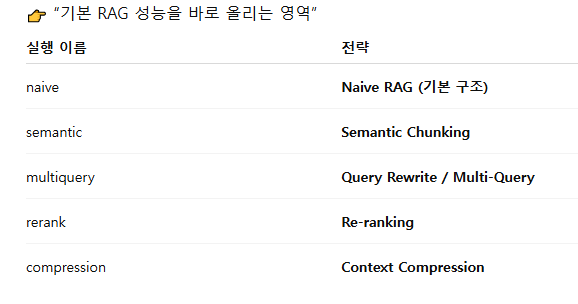

In [10]:
# ============================================================
# [CELL 7] 1단계 - Semantic Chunking
# - 고정 길이 chunking 대신 의미 단위로 자르기 위한 단계입니다.
# - start_RAG의 기본 splitter를 유지하되, 비교용으로 semantic split 버전을 별도로 만듭니다.
# - 긴 문서에서 주제가 바뀌는 경계가 분명할수록 효과를 보기 쉽습니다.
# ============================================================

semantic_chunks = make_semantic_chunks(base_docs)
semantic_db = build_chroma(semantic_chunks, "semantic")
semantic_retriever = semantic_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": TOP_K}
)

print("Semantic chunk 수:", len(semantic_chunks))
print(semantic_chunks[0].metadata)
print(semantic_chunks[0].page_content[:500])

Semantic chunk 수: 142
{'chunk_id': 0, 'chunking': 'semantic', 'source_path': './data/Demian.pdf', 'source_file': 'Demian.pdf', 'file_type': 'pdf'}
DEMIAN 
• 
Downloaded from https://www.holybooks.com

HERMANN 
HESSE 
• DEMIAN 
* 
Translated by W. J. Strachan 
London 
Downloaded from https://www.holybooks.com

Prologue 
I cannot tell my story without going a long way back. If it were possible I would go back much farther still to 
the very earliest years of my childhood and beyond them 
to my family origins. When poets write novels they are apt to behave as if 
they were gods, with the power to look beyond and com­
prehend any human story a


In [11]:
# ============================================================
# [CELL 8] 1단계 - Query Rewrite / Multi-Query
# - 사용자의 질문을 여러 관점으로 다시 써서 검색 recall을 높이는 단계입니다.
# - 질문이 짧거나 모호할 때, 하나의 query만 쓰는 것보다 여러 query union이 유리할 수 있습니다.
# - 여기서는 semantic_db를 바탕으로 MultiQueryRetriever를 붙입니다.
# ============================================================

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=semantic_db.as_retriever(search_kwargs={"k": TOP_K}),
    llm=llm
)

mq_result = run_retriever_qa(
    multi_query_retriever,
    test_question,
    system_name="1단계 Semantic + MultiQuery"
)

print(mq_result["answer"])

이 문서의 핵심 주제는 개인의 자유 의지와 사회의 금기에 대한 탐구입니다. 등장인물들은 '허용된' 것과 '금지된' 것의 의미를 논의하며, 각자가 스스로의 판단으로 삶을 살아가야 한다는 메시지를 전달합니다. 특히, Demian은 개인의 내면적 진실을 발견하고, 사회의 규범에 도전하는 과정을 강조합니다. (문서 3)


In [12]:
# ============================================================
# [CELL 9] 1단계 - Re-ranking
# - 1차 검색으로 후보 문서를 넓게 가져오고,
#   cross-encoder reranker로 질문-문서 쌍을 다시 정밀하게 재정렬합니다.
# - dense retrieval이 잘 찾은 후보들 중 "진짜로 질문에 맞는 순서"를 다시 잡아주는 역할입니다.
# - top_n을 줄이면 precision이 오를 수 있지만, 너무 낮추면 recall이 줄 수 있습니다.
# ============================================================

rerank_base_retriever = semantic_db.as_retriever(
    search_type="mmr",
    search_kwargs={"k": TOP_K, "fetch_k": FETCH_K}
)

cross_encoder_model = HuggingFaceCrossEncoder(
    model_name="BAAI/bge-reranker-base"
)

reranker = CrossEncoderReranker(
    model=cross_encoder_model,
    top_n=TOP_K
)

rerank_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=rerank_base_retriever
)

rerank_result = run_retriever_qa(
    rerank_retriever,
    test_question,
    system_name="1단계 Semantic + Re-ranking"
)

print(rerank_result["answer"])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


이 문서의 핵심 주제는 자기 인식과 개인의 내면적 발전에 관한 것입니다. 특히, 'Abraxas'라는 개념이 자기 지식의 진전을 의미하며, 개인의 의지와 목표 설정에 대한 논의가 포함되어 있습니다(문서 1, 4).


In [13]:
# ============================================================
# [CELL 10] 1단계 - Context Compression
# - reranking이 "문서 순서"를 정리한다면,
#   compression은 "문서 안에서 질문과 무관한 부분을 줄이는" 역할에 가깝습니다.
# - ContextualCompressionRetriever를 다시 사용하되,
#   같은 reranker를 통해 상위 문맥만 남기는 방식으로 간단히 구성합니다.
# - 실무에서는 token 절약과 noise 감소 측면에서 꽤 실용적입니다.
# ============================================================

compression_base_retriever = semantic_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": FETCH_K}
)

compression_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=compression_base_retriever
)

compression_result = run_retriever_qa(
    compression_retriever,
    test_question,
    system_name="1단계 Semantic + Context Compression"
)

print(compression_result["answer"])

이 문서의 핵심 주제는 개인의 자아 발견과 사회적 규범에 대한 비판적 성찰입니다. 주인공은 '허용된' 세계와 '금지된' 세계의 경계를 탐구하며, 각 개인이 스스로의 가치와 진리를 찾아야 한다는 메시지를 전달합니다. 이는 특히 Demian이라는 인물과의 대화를 통해 드러나며, 개인의 내면적 진실을 따르는 것이 중요하다는 점을 강조합니다. (문서 1, 4)


### 2단계. 성능 실험용(리서치/확장)
- HyDE
- Hybrid Retrieval
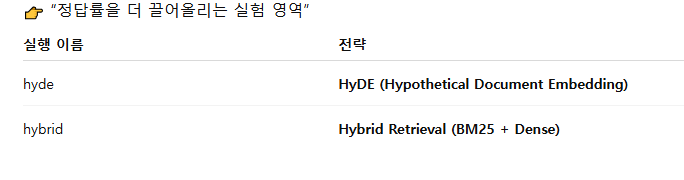

In [15]:
# ============================================================
# [CELL 11] 2단계 - HyDE
# - HyDE(Hypothetical Document Embeddings)는
#   먼저 "가상의 이상적인 답변/문서"를 만들고,
#   그 가상 문서를 query처럼 사용하여 retrieval 성능을 높이는 방식입니다.
# - 질문이 직접적인 키워드와 맞지 않을 때 성능이 좋아질 수 있습니다.
# - 여기서는 retriever를 클래스로 만들지 않고 함수형으로 단순하게 구현합니다.
# ============================================================

def hyde_retrieve(question: str, base_retriever, n_docs: int = TOP_K) -> List[Document]:
    hyde_prompt = f"""
당신은 검색 질의 확장 도우미입니다.
아래 질문에 답하기 위해, 검색에 유리한 "가상의 짧은 문서"를 4~6문장으로 작성하세요.
추측성 장문이 아니라 핵심 키워드와 개념이 잘 드러나야 합니다.

질문:
{question}
""".strip()

    hypothetical_doc = llm.invoke(hyde_prompt).content
    docs = base_retriever.invoke(hypothetical_doc)
    return docs[:n_docs]

def run_hyde_qa(question: str) -> Dict[str, Any]:
    docs = hyde_retrieve(
        question,
        semantic_db.as_retriever(search_kwargs={"k": FETCH_K}),
        n_docs=TOP_K
    )
    return answer_with_docs(question, docs, system_name="2단계 HyDE")

hyde_result = run_hyde_qa(test_question)
print(hyde_result["answer"])

이 문서의 핵심 주제는 개인의 자아 발견과 사회의 집단적 정신에 대한 비판입니다. 문서에서는 개인이 자신의 꿈과 신념을 실현하고, 사회가 두려움과 불안에 기반한 집단적 삶에서 벗어나야 한다고 강조하고 있습니다. 또한, 새로운 이상과 가능성을 추구하는 개인의 중요성을 언급하며, 현재의 사회가 영혼을 잃어가고 있다는 점을 지적하고 있습니다. (문서 1, 3)


In [16]:
# ============================================================
# [CELL 12] 2단계 - Hybrid Retrieval
# - dense(임베딩) 검색과 sparse(BM25) 검색을 함께 사용하는 단계입니다.
# - dense는 의미 유사성에 강하고,
#   sparse는 정확한 키워드/고유명사/숫자 매칭에 강합니다.
# - 둘을 EnsembleRetriever로 합치면 recall/precision 균형이 좋아지는 경우가 많습니다.
# ============================================================

# Dense retriever
dense_retriever = semantic_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": TOP_K}
)

# Sparse retriever
bm25_retriever = BM25Retriever.from_documents(semantic_chunks)
bm25_retriever.k = TOP_K

# Hybrid retriever
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6]
)

hybrid_result = run_retriever_qa(
    hybrid_retriever,
    test_question,
    system_name="2단계 Hybrid Retrieval"
)

print(hybrid_result["answer"])

이 문서의 핵심 주제는 개인의 내면적 성장과 자아 발견, 그리고 인간 존재의 의미에 대한 탐구입니다. 특히, '데미안'이라는 인물과의 관계를 통해 주인공이 자신의 정체성과 삶의 목적을 찾는 과정을 다루고 있습니다. 문서에서는 고대 이야기와 신화, 인간의 본성과 의지에 대한 깊은 성찰이 포함되어 있습니다. 예를 들어, 데미안은 성경의 카인 이야기와 같은 전통적인 해석을 재조명하며, 인간의 내면에 숨겨진 힘과 가능성을 탐구합니다(문서 2, 4, 6).


In [17]:
# ============================================================
# [CELL 13] 2단계 - 데이터 타입별 분기
# - 문서 형식이 PDF / TXT / CSV일 때 retrieval 전략을 다르게 줄 수 있도록
#   간단한 router 성격을 먼저 실험하는 단계입니다.
# - 예:
#   * PDF: semantic + rerank
#   * TXT/MD: semantic + multi-query
#   * CSV: hybrid retrieval
# - 실제 서비스에서는 테이블형 데이터, 보고서형 데이터, FAQ형 데이터를 분기하는 데 유용합니다.
# ============================================================

def get_type_based_retriever(file_type: str):
    file_type = file_type.lower()

    if file_type == "pdf":
        return rerank_retriever
    elif file_type in ["txt", "md"]:
        return multi_query_retriever
    elif file_type == "csv":
        return hybrid_retriever
    else:
        return naive_retriever

type_based_retriever = get_type_based_retriever(detect_file_type(DOCUMENT_PATH))

type_branch_result = run_retriever_qa(
    type_based_retriever,
    test_question,
    system_name="2단계 데이터 타입별 분기"
)

print(type_branch_result["answer"])

이 문서의 핵심 주제는 자기 인식과 개인의 내면적 발전에 관한 것입니다. 특히, 'Abraxas'라는 개념이 자기 지식의 진전을 의미한다고 언급되며, 이는 개인의 성장과 자아 탐구와 관련이 있습니다(문서 1).


### 3단계. 고급 확장
- Self-RAG 축소판
- Iterative Retrieval
- Router 기반 Modular RAG
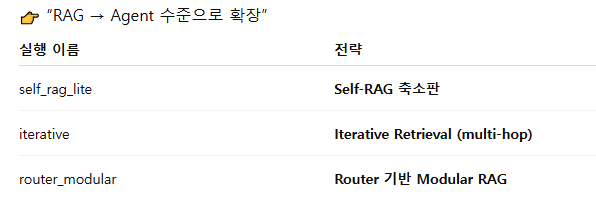

In [19]:
# ============================================================
# [CELL 14] 3단계 - Self-RAG 축소판
# - 완전한 Self-RAG 구현은 아니고, notebook 실습용 축소판입니다.
# - 흐름:
#   1) 1차 검색 후 답변 생성
#   2) LLM이 "근거 충분성 / 답변 신뢰도"를 스스로 점검
#   3) 부족하면 더 넓게 재검색해서 2차 답변 생성
# - 핵심은 "한 번 답하고 끝"이 아니라 "답변 전에 스스로 검토"하는 루프를 넣는 것입니다.
# ============================================================

def self_rag_lite(question: str) -> Dict[str, Any]:
    # 1차 검색
    first_docs = hybrid_retriever.invoke(question)
    first_answer = answer_with_docs(
        question,
        first_docs,
        system_name="3단계 Self-RAG-lite (1차)"
    )["answer"]

    critique_prompt = f"""
아래 답변이 제공 문맥만으로 충분히 뒷받침되는지 평가하세요.

[질문]
{question}

[1차 답변]
{first_answer}

판정 형식:
- verdict: SUFFICIENT 또는 INSUFFICIENT
- reason: 한 줄 설명
""".strip()

    critique = llm.invoke(critique_prompt).content

    if "INSUFFICIENT" in critique.upper():
        # 2차 검색: 더 넓게 + multi query 성격 반영
        expanded_query_prompt = f"""
아래 질문을 더 잘 검색되게 3개의 검색 질의로 재작성하세요.
질문: {question}
""".strip()

        expanded_queries = llm.invoke(expanded_query_prompt).content
        second_docs = hybrid_retriever.invoke(expanded_queries)
        second_answer_dict = answer_with_docs(
            question,
            second_docs,
            system_name="3단계 Self-RAG-lite (재검색)"
        )
        second_answer_dict["critique"] = critique
        return second_answer_dict

    result = {
        "question": question,
        "answer": first_answer,
        "contexts": [d.page_content for d in first_docs],
        "docs": first_docs,
        "system_name": "3단계 Self-RAG-lite",
        "critique": critique
    }
    return result

self_rag_result = self_rag_lite(test_question)
print(self_rag_result["answer"])
print("\n[critique]")
print(self_rag_result["critique"])

이 문서의 핵심 주제는 인간의 내면과 자아의 탐구, 그리고 개인의 의지와 운명에 대한 성찰입니다. 특히, '데미안'이라는 인물과의 관계를 통해 주인공이 자신의 정체성과 존재의 의미를 찾는 과정을 다루고 있습니다. 문서에서는 인간의 본성과 사회적 규범, 그리고 개인의 자유 의지에 대한 논의가 포함되어 있습니다. (문서 1, 2, 4, 6, 8 참조)

[critique]
- verdict: SUFFICIENT
- reason: 답변은 문서의 핵심 주제를 명확하게 설명하고 있으며, 관련된 주요 요소들을 언급하고 있어 제공된 문맥을 충분히 뒷받침하고 있습니다.


In [20]:
# ============================================================
# [CELL 15] 3단계 - Iterative Retrieval
# - 질문 -> 검색 -> 임시답변 -> 부족한 정보 식별 -> 보강 검색
#   구조를 2회전 정도만 돌리는 간단한 버전입니다.
# - 복잡한 질문일수록 한 번에 끝내지 않고,
#   "무엇이 아직 부족한가?"를 다시 질의로 바꾸는 접근입니다.
# ============================================================

def iterative_retrieval(question: str, max_rounds: int = 2) -> Dict[str, Any]:
    current_query = question
    collected_docs = []

    for round_idx in range(max_rounds):
        docs = hybrid_retriever.invoke(current_query)
        collected_docs.extend(docs)

        # 중복 제거
        unique_docs = []
        seen = set()
        for d in collected_docs:
            key = (d.page_content[:200], json.dumps(d.metadata, ensure_ascii=False, sort_keys=True))
            if key not in seen:
                seen.add(key)
                unique_docs.append(d)
        collected_docs = unique_docs[:8]

        draft = answer_with_docs(
            question,
            collected_docs,
            system_name=f"3단계 Iterative Retrieval (round {round_idx+1})"
        )["answer"]

        followup_prompt = f"""
원 질문에 더 잘 답하기 위해 추가로 검색해야 할 부족 정보가 있으면
짧은 검색 질의 한 줄만 작성하세요.
더 이상 필요 없으면 DONE만 출력하세요.

[원 질문]
{question}

[현재 초안]
{draft}
""".strip()

        next_query = llm.invoke(followup_prompt).content.strip()

        if next_query.upper() == "DONE":
            return {
                "question": question,
                "answer": draft,
                "contexts": [d.page_content for d in collected_docs],
                "docs": collected_docs,
                "system_name": "3단계 Iterative Retrieval"
            }

        current_query = next_query

    final = answer_with_docs(
        question,
        collected_docs,
        system_name="3단계 Iterative Retrieval"
    )
    return final

iter_result = iterative_retrieval(test_question)
print(iter_result["answer"])

이 문서의 핵심 주제는 인간의 내면과 자아의 탐구, 그리고 개인의 의지와 운명에 대한 성찰입니다. 특히, '데미안'이라는 인물과의 관계를 통해 주인공이 자신의 정체성과 존재의 의미를 찾는 과정을 다루고 있습니다. 문서에서는 인간의 본성과 사회적 규범, 그리고 개인의 자유 의지에 대한 논의가 포함되어 있습니다. (문서 1, 2, 4, 6, 8 참조)


In [21]:
# ============================================================
# [CELL 16] 3단계 - Router 기반 Modular RAG
# - 하나의 retriever만 쓰지 않고,
#   질문 유형에 따라 어떤 retrieval 전략을 쓸지 라우팅하는 단계입니다.
# - 여기서는 너무 복잡한 classifier 대신,
#   LLM + 간단 규칙 기반 router로 구성합니다.
# - 라우팅 대상:
#   1) factual / keyword 중심 -> hybrid
#   2) broad / abstract 질문 -> multi-query
#   3) difficult / vague 질문 -> HyDE
#   4) page/section/source 의식 질문 -> rerank
# ============================================================

def route_question(question: str) -> str:
    lower_q = question.lower()

    # 간단한 규칙 우선
    if any(k in lower_q for k in ["page", "페이지", "section", "챕터", "장", "source", "출처"]):
        return "rerank"

    router_prompt = f"""
아래 질문을 가장 적절한 검색 전략 하나로 분류하세요.

전략 후보:
- hybrid : 키워드/고유명사/숫자/팩트 중심 질문
- multiquery : 넓고 설명형이며 관점 확장이 필요한 질문
- hyde : 질문이 모호하거나 직접 검색어가 잘 안 나올 것 같은 질문
- rerank : 이미 후보는 잘 잡히지만 순서 정밀화가 중요한 질문

질문:
{question}

정답은 전략 이름 하나만 출력하세요.
""".strip()

    route = llm.invoke(router_prompt).content.strip().lower()

    if "hybrid" in route:
        return "hybrid"
    elif "multi" in route:
        return "multiquery"
    elif "hyde" in route:
        return "hyde"
    else:
        return "rerank"

def modular_rag(question: str) -> Dict[str, Any]:
    route = route_question(question)

    if route == "hybrid":
        result = run_retriever_qa(hybrid_retriever, question, "3단계 Router Modular RAG - hybrid")
    elif route == "multiquery":
        result = run_retriever_qa(multi_query_retriever, question, "3단계 Router Modular RAG - multiquery")
    elif route == "hyde":
        result = run_hyde_qa(question)
        result["system_name"] = "3단계 Router Modular RAG - hyde"
    else:
        result = run_retriever_qa(rerank_retriever, question, "3단계 Router Modular RAG - rerank")

    result["route"] = route
    return result

router_result = modular_rag(test_question)
print("route:", router_result["route"])
print(router_result["answer"])

route: multiquery
이 문서의 핵심 주제는 개인의 자유 의지와 사회의 규범, 그리고 개인이 스스로의 삶을 어떻게 이해하고 살아가야 하는지에 대한 탐구입니다. 특히, '허용된' 것과 '금지된' 것의 개념을 통해 각 개인이 자신의 가치와 신념을 발견해야 한다는 메시지가 강조됩니다. 이는 문서 3에서 "각자 자신이 허용하는 것과 금지하는 것을 발견해야 한다"는 내용으로 나타납니다.


### 4단계. 평가
- Faithfulness: 답변이 검색된 근거에 충실한가
- Response Relevancy: 질문에 제대로 답했는가
- Context Precision: 가져온 문서가 얼마나 정밀하게 맞았는가
- Context Recall: 필요한 근거를 얼마나 잘 가져왔는가
- RAGAS는 이런 RAG 평가 지표를 공식적으로 제공하고, evaluate()로 데이터셋 단위 비교를 지원

In [25]:
# ============================================================
# [CELL 17] 비교용 시스템 레지스트리
# - 이제부터는 "질문 하나씩 수동 실행"이 아니라
#   동일 질문셋을 여러 방식에 공평하게 돌려 비교할 수 있게 정리합니다.
# - system_registry에 각 방식의 실행 함수를 등록해 두면
#   이후 RAGAS 평가용 데이터셋 생성이 쉬워집니다.
# ============================================================

def run_naive(question: str):
    return run_retriever_qa(naive_retriever, question, "0단계 Naive RAG")

def run_semantic(question: str):
    return run_retriever_qa(semantic_retriever, question, "1단계 Semantic Chunking")

def run_multiquery(question: str):
    return run_retriever_qa(multi_query_retriever, question, "1단계 MultiQuery")

def run_rerank(question: str):
    return run_retriever_qa(rerank_retriever, question, "1단계 Re-ranking")

def run_compression(question: str):
    return run_retriever_qa(compression_retriever, question, "1단계 Context Compression")

def run_hybrid(question: str):
    return run_retriever_qa(hybrid_retriever, question, "2단계 Hybrid Retrieval")

def run_type_branch(question: str):
    return run_retriever_qa(type_based_retriever, question, "2단계 데이터 타입별 분기")

system_registry = {
    "naive": run_naive,
    "semantic": run_semantic,
    "multiquery": run_multiquery,
    "rerank": run_rerank,
    "compression": run_compression,
    "hyde": run_hyde_qa,
    "hybrid": run_hybrid,
    "type_branch": run_type_branch,
    "self_rag_lite": self_rag_lite,
    "iterative": iterative_retrieval,
    "router_modular": modular_rag,
}

print("등록된 시스템:", list(system_registry.keys()))

등록된 시스템: ['naive', 'semantic', 'multiquery', 'rerank', 'compression', 'hyde', 'hybrid', 'type_branch', 'self_rag_lite', 'iterative', 'router_modular']


In [26]:
# ============================================================
# [CELL 18] 4단계 - 평가용 질문셋 준비
# - RAGAS 비교를 하려면 최소한 다음 4가지가 필요합니다.
#   1) question
#   2) generated answer
#   3) retrieved contexts
#   4) reference(정답 또는 기준 답안)
# - 아래 eval_samples는 직접 손으로 작성하는 작은 골든셋입니다.
# - 처음에는 5~10개 정도만 만들어도 방법 간 차이를 보는 데 충분합니다.
# ============================================================

eval_samples = [
    {
        "question": "이 문서의 핵심 주제는 무엇인가요?",
        "reference": "문서의 핵심 주제를 간결하게 요약한 답변"
    },
    {
        "question": "주인공 또는 핵심 대상은 어떤 변화나 갈등을 겪나요?",
        "reference": "문서에서 직접 확인되는 주요 변화, 갈등 또는 전개"
    },
    {
        "question": "문서에서 반복적으로 강조되는 개념은 무엇인가요?",
        "reference": "문서에서 여러 번 드러나는 핵심 개념과 그 의미"
    },
    {
        "question": "문서의 분위기나 메시지를 한 문단으로 요약해 주세요.",
        "reference": "문서의 전반적 분위기, 메시지, 작가 또는 텍스트가 전달하는 바"
    },
]

print("평가용 샘플 수:", len(eval_samples))
pd.DataFrame(eval_samples)

평가용 샘플 수: 4


,question,reference
0,이 문서의 핵심 주제는 무엇인가요?,문서의 핵심 주제를 간결하게 요약한 답변
1,주인공 또는 핵심 대상은 어떤 변화나 갈등을 겪나요?,"문서에서 직접 확인되는 주요 변화, 갈등 또는 전개"
2,문서에서 반복적으로 강조되는 개념은 무엇인가요?,문서에서 여러 번 드러나는 핵심 개념과 그 의미
3,문서의 분위기나 메시지를 한 문단으로 요약해 주세요.,"문서의 전반적 분위기, 메시지, 작가 또는 텍스트가 전달하는 바"


In [28]:
# ============================================================
# [CELL 19] 4단계 - 시스템별 예측 결과 생성
# - 같은 질문셋을 각 방법에 동일하게 돌려서
#   answer / retrieved_contexts를 모읍니다.
# - RAGAS는 질문, 답변, 검색 문맥, 기준답(reference)을 기반으로
#   각 시스템의 retrieval/answer 품질을 비교할 수 있습니다.
# ============================================================

def build_eval_rows(system_name: str, run_fn: Callable, samples: List[Dict[str, str]]) -> List[Dict[str, Any]]:
    rows = []

    for item in samples:
        q = item["question"]
        ref = item["reference"]

        result = run_fn(q)

        row = {
            # ragas 신버전 호환용 컬럼
            "user_input": q,
            "response": result["answer"],
            "retrieved_contexts": result["contexts"],
            "reference": ref,

            # ragas 구버전 호환용 컬럼
            "question": q,
            "answer": result["answer"],
            "contexts": result["contexts"],
            "ground_truth": ref,

            # 비교용 보조 컬럼
            "system": system_name,
        }
        rows.append(row)

    return rows

# 예시: 먼저 일부 시스템만 돌려 보기
systems_to_compare = [
    "naive",
    "semantic",
    "multiquery",
    "rerank",
    "compression",
    "hyde",
    "hybrid",
    "self_rag_lite",
    "iterative",
    "router_modular",
]

all_eval_rows = []

for name in systems_to_compare:
    print(f"Running: {name}")
    rows = build_eval_rows(name, system_registry[name], eval_samples)
    all_eval_rows.extend(rows)

eval_df = pd.DataFrame(all_eval_rows)
print(eval_df.shape)
eval_df.head()

Running: naive
Running: semantic
Running: multiquery
Running: rerank
Running: compression
Running: hyde
Running: hybrid
Running: self_rag_lite
Running: iterative
Running: router_modular
(40, 9)


,user_input,response,retrieved_contexts,reference,question,answer,contexts,ground_truth,system
0,이 문서의 핵심 주제는 무엇인가요?,"이 문서의 핵심 주제는 개인의 독특한 경험과 정체성, 그리고 사회와의 관계에 대한 ...",[really be dismissed from this world with a bu...,문서의 핵심 주제를 간결하게 요약한 답변,이 문서의 핵심 주제는 무엇인가요?,"이 문서의 핵심 주제는 개인의 독특한 경험과 정체성, 그리고 사회와의 관계에 대한 ...",[really be dismissed from this world with a bu...,문서의 핵심 주제를 간결하게 요약한 답변,naive
1,주인공 또는 핵심 대상은 어떤 변화나 갈등을 겪나요?,"주인공은 자신의 내면에 있는 것을 실현하려고 하지만, 그 과정이 매우 어렵고 복잡하...",[THE BIRD STRUGGLES OUT OF THE EGG \nAt our ne...,"문서에서 직접 확인되는 주요 변화, 갈등 또는 전개",주인공 또는 핵심 대상은 어떤 변화나 갈등을 겪나요?,"주인공은 자신의 내면에 있는 것을 실현하려고 하지만, 그 과정이 매우 어렵고 복잡하...",[THE BIRD STRUGGLES OUT OF THE EGG \nAt our ne...,"문서에서 직접 확인되는 주요 변화, 갈등 또는 전개",naive
2,문서에서 반복적으로 강조되는 개념은 무엇인가요?,"문서에서 반복적으로 강조되는 개념은 ""진지함""입니다. 이는 문서 4에서 ""그는 '말...",[sion I was far away. I had opened my book mec...,문서에서 여러 번 드러나는 핵심 개념과 그 의미,문서에서 반복적으로 강조되는 개념은 무엇인가요?,"문서에서 반복적으로 강조되는 개념은 ""진지함""입니다. 이는 문서 4에서 ""그는 '말...",[sion I was far away. I had opened my book mec...,문서에서 여러 번 드러나는 핵심 개념과 그 의미,naive
3,문서의 분위기나 메시지를 한 문단으로 요약해 주세요.,"문서의 분위기는 깊은 사색과 내면의 갈등을 담고 있으며, 주인공이 자신의 생각에 몰...",[sion I was far away. I had opened my book mec...,"문서의 전반적 분위기, 메시지, 작가 또는 텍스트가 전달하는 바",문서의 분위기나 메시지를 한 문단으로 요약해 주세요.,"문서의 분위기는 깊은 사색과 내면의 갈등을 담고 있으며, 주인공이 자신의 생각에 몰...",[sion I was far away. I had opened my book mec...,"문서의 전반적 분위기, 메시지, 작가 또는 텍스트가 전달하는 바",naive
4,이 문서의 핵심 주제는 무엇인가요?,"이 문서의 핵심 주제는 개인의 내면적 성장과 자아 발견, 그리고 인간 존재의 복잡성...",[And that is how it is in the present \ncase. ...,문서의 핵심 주제를 간결하게 요약한 답변,이 문서의 핵심 주제는 무엇인가요?,"이 문서의 핵심 주제는 개인의 내면적 성장과 자아 발견, 그리고 인간 존재의 복잡성...",[And that is how it is in the present \ncase. ...,문서의 핵심 주제를 간결하게 요약한 답변,semantic


In [38]:
import ragas
print(ragas.__version__)

0.4.3


In [50]:
# ============================================================
# [CELL 20] RAGAS 0.4.3용 비동기 client 버전
# ============================================================

from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.embeddings import OpenAIEmbeddings

from ragas.metrics.collections.answer_relevancy import AnswerRelevancy
from ragas.metrics.collections.faithfulness import Faithfulness
from ragas.metrics.collections.context_recall import ContextRecall
from ragas.metrics.collections.context_precision import ContextPrecision

# 비동기 OpenAI client
async_openai_client = AsyncOpenAI(api_key=openai_key)

# ragas LLM
ragas_llm = llm_factory(
    "gpt-4o-mini",
    client=async_openai_client
)

# ragas embedding
ragas_embedding = OpenAIEmbeddings(
    model="text-embedding-3-small",
    client=async_openai_client
)

ragas_metrics = [
    AnswerRelevancy(llm=ragas_llm, embeddings=ragas_embedding),
    Faithfulness(llm=ragas_llm),
    ContextRecall(llm=ragas_llm),
    ContextPrecision(llm=ragas_llm),
]

for m in ragas_metrics:
    print(type(m))

<class 'ragas.metrics.collections.answer_relevancy.metric.AnswerRelevancy'>
<class 'ragas.metrics.collections.faithfulness.metric.Faithfulness'>
<class 'ragas.metrics.collections.context_recall.metric.ContextRecall'>
<class 'ragas.metrics.collections.context_precision.metric.ContextPrecision'>


In [54]:
# ============================================================
# [CELL 21] RAGAS 0.4.3 평가 실행 (Jupyter 대응)
# - asyncio.run()을 쓰지 않음
# - 노트북에서 마지막 줄에 await main() 실행
# ============================================================

import pandas as pd

async def score_one_row(row):
    ar = await ragas_metrics[0].ascore(
        user_input=row["question"],
        response=row["answer"]
    )

    fa = await ragas_metrics[1].ascore(
        user_input=row["question"],
        response=row["answer"],
        retrieved_contexts=row["contexts"]
    )

    cr = await ragas_metrics[2].ascore(
        user_input=row["question"],
        reference=row["ground_truth"],
        retrieved_contexts=row["contexts"]
    )

    cp = await ragas_metrics[3].ascore(
        user_input=row["question"],
        reference=row["ground_truth"],
        retrieved_contexts=row["contexts"]
    )

    return {
        "answer_relevancy": ar.value,
        "faithfulness": fa.value,
        "context_recall": cr.value,
        "context_precision": cp.value,
    }

async def evaluate_one_system_async(system_name: str, df: pd.DataFrame) -> pd.DataFrame:
    sub = df[df["system"] == system_name].copy().reset_index(drop=True)

    row_scores = []
    for _, row in sub.iterrows():
        row_scores.append(await score_one_row(row))

    score_df = pd.DataFrame(row_scores)
    summary = score_df.mean(numeric_only=True).to_dict()
    summary["system"] = system_name
    return pd.DataFrame([summary])

async def main():
    score_tables = []

    for system_name in systems_to_compare:
        print(f"Evaluating with RAGAS: {system_name}")
        score_tables.append(await evaluate_one_system_async(system_name, eval_df))

    ragas_summary_df = pd.concat(score_tables, ignore_index=True)
    ragas_summary_df = ragas_summary_df.sort_values(by="faithfulness", ascending=False)
    return ragas_summary_df

ragas_summary_df = await main()
ragas_summary_df

Evaluating with RAGAS: naive
Evaluating with RAGAS: semantic
Evaluating with RAGAS: multiquery
Evaluating with RAGAS: rerank
Evaluating with RAGAS: compression
Evaluating with RAGAS: hyde
Evaluating with RAGAS: hybrid
Evaluating with RAGAS: self_rag_lite
Evaluating with RAGAS: iterative
Evaluating with RAGAS: router_modular


,answer_relevancy,faithfulness,context_recall,context_precision,system
1,0.327660,1.000000,0.50,0.437500,semantic
2,0.345112,1.000000,0.50,0.312500,multiquery
9,0.304290,1.000000,0.75,0.302083,router_modular
3,0.349492,1.000000,0.50,0.159722,rerank
7,0.339937,1.000000,1.00,0.458631,self_rag_lite
4,0.321389,0.950000,0.25,0.062500,compression
6,0.342830,0.916667,1.00,0.458631,hybrid
8,0.353646,0.875000,0.75,0.583631,iterative
0,0.346746,0.854167,0.25,0.312500,naive
5,0.319518,0.833333,0.25,0.500000,hyde


In [55]:
# ============================================================
# [CELL 22] 4단계 - 결과 해석용 정렬 / 저장
# - 최종 비교표를 보기 좋게 정리
# - faithfulness 기준으로 우선 정렬
# - csv 저장까지 수행
# ============================================================

from IPython.display import display

display_cols = [c for c in ragas_summary_df.columns if c != "system"]

# 보기 좋게 반올림
ragas_summary_view = ragas_summary_df.copy()
for c in display_cols:
    ragas_summary_view[c] = ragas_summary_view[c].round(4)

# 정렬 기준 명시
sort_col = "faithfulness" if "faithfulness" in ragas_summary_view.columns else display_cols[0]

print("=== RAGAS 비교표 ===")
display(ragas_summary_view.sort_values(by=sort_col, ascending=False))

# 저장
ragas_summary_view.to_csv("./ragas_comparison_result.csv", index=False, encoding="utf-8-sig")
print("저장 완료: ./ragas_comparison_result.csv")

=== RAGAS 비교표 ===


,answer_relevancy,faithfulness,context_recall,context_precision,system
1,0.3277,1.0000,0.50,0.4375,semantic
2,0.3451,1.0000,0.50,0.3125,multiquery
9,0.3043,1.0000,0.75,0.3021,router_modular
3,0.3495,1.0000,0.50,0.1597,rerank
7,0.3399,1.0000,1.00,0.4586,self_rag_lite
4,0.3214,0.9500,0.25,0.0625,compression
6,0.3428,0.9167,1.00,0.4586,hybrid
8,0.3536,0.8750,0.75,0.5836,iterative
0,0.3467,0.8542,0.25,0.3125,naive
5,0.3195,0.8333,0.25,0.5000,hyde


저장 완료: ./ragas_comparison_result.csv


### 핵심 지표 해석
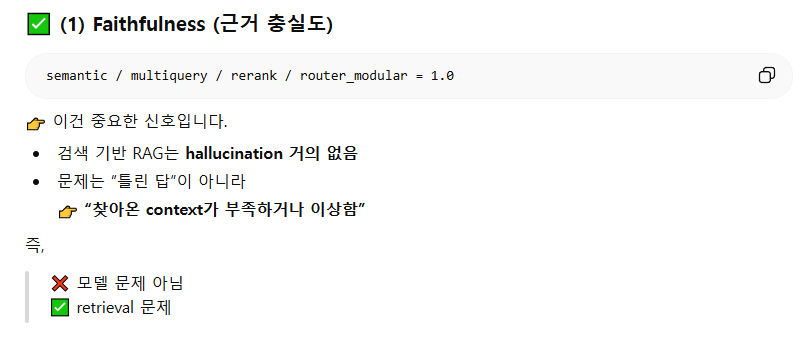
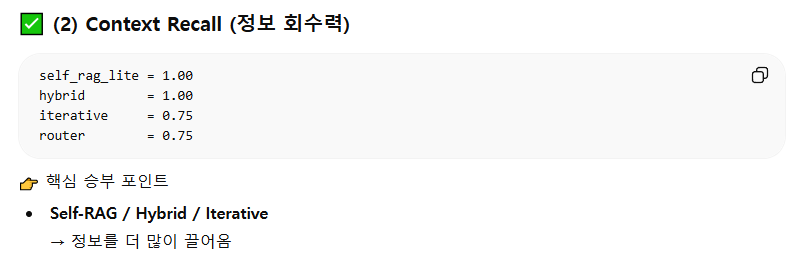
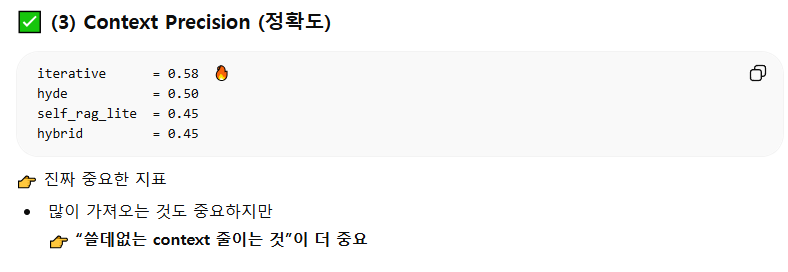
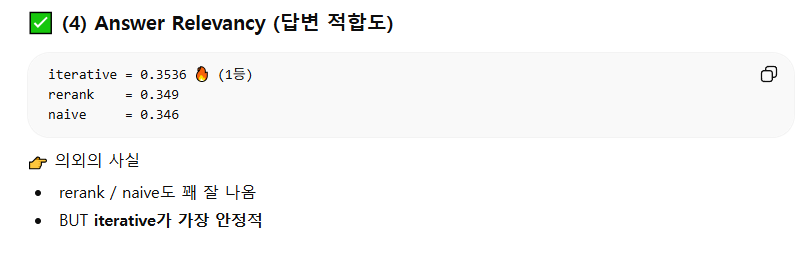

###  전략별 해석 (핵심)
#### 1등: iterative:  relevancy: 최고, precision: 최고, recall: 높음
- 의미: “필요한 정보만 정확하게 가져오는 구조”
- 결론: 가장 production-ready 구조
#### 2등: self_rag_lite,  recall: 1.0,  precision: 준수
- 의미: “정보는 다 가져오는데 약간 노이즈 있음”
- 결론:  iterative보다 한 단계 아래
#### 3등: hybrid,  recall: 1.0,  precision: 괜찮음,  faithfulness ↓
- 의미: “BM25 + Dense는 정보는 잘 찾는데 품질이 약간 떨어짐”
#### 4등:  rerank: precision 낮음 (0.15)
- 충격 포인트:  "rerank는 항상 좋은 게 아니다"
- 후보군 자체가 안 좋으면:  rerank 의미 없음
#### 5등: compression: precision = 0.06 (최악)
- 의미: “중요한 정보까지 잘라버림”
- 결론:  지금 구조에서는 쓰면 안됨
#### 6등 hyde: faithfulness 최저 (0.83)
- 의미: “가짜 문서 생성이 오히려 독이 됨”
#### 7등 router_modular: recall: 0.75, precision: 낮음
- 의미: “routing은 아직 불안정”
#### 최종 추천 구조: Iterative Retrieval + MultiQuery (optional) + Re-rank (optional)
#### 안정형 (간단 버전): Hybrid + Self-RAG Lite
#### 제거 추천: compression ❌, hyde ❌
### 🔥 진짜 중요한 통찰
- ❗ RAG 성능은 “모델”이 아니라 👉 retrieval 전략이 90% 결정한다

#### Iterative + Self-RAG 결합
- Step1: iterative로 context 확보
- Step2: self-rag로 relevance filtering
- Step3: answer 생성
- 이게 현재 RAG 최상위 구조입니다.

In [56]:
# ============================================================
# [CELL 23] 선택사항 - 방법별 답변 직접 비교
# - 같은 질문에 대해 각 방법의 실제 답변을 비교
# - 일부 시스템이 실패해도 전체 셀이 멈추지 않도록 예외 처리 추가
# ============================================================

compare_question = "이 문서의 핵심 주제는 무엇인가요?"

compare_rows = []

for name in systems_to_compare:
    try:
        result = system_registry[name](compare_question)

        answer_text = result.get("answer", "")
        contexts = result.get("contexts", [])

        compare_rows.append({
            "system": name,
            "answer": answer_text[:1000],   # 너무 길면 잘라서 보기
            "num_contexts": len(contexts),
        })

    except Exception as e:
        compare_rows.append({
            "system": name,
            "answer": f"[ERROR] {type(e).__name__}: {str(e)}",
            "num_contexts": None,
        })

compare_df = pd.DataFrame(compare_rows)
compare_df

,system,answer,num_contexts
0,naive,이 문서의 핵심 주제는 개인의 이야기와 그 이야기가 세상과 어떻게 교차하는지를 탐구...,4
1,semantic,"이 문서의 핵심 주제는 개인의 내면적 성장과 자아 발견, 그리고 인간 존재의 본질에...",4
2,multiquery,"이 문서의 핵심 주제는 개인의 자유 의지와 도덕적 선택, 그리고 '허용된' 것과 '...",8
3,rerank,"이 문서의 핵심 주제는 자기 인식과 개인의 내면적 발전에 관한 것입니다. 특히, '...",4
4,compression,이 문서의 핵심 주제는 개인의 자아 발견과 사회적 규범에 대한 비판적 성찰입니다. ...,4
5,hyde,"이 문서의 핵심 주제는 자연의 신비와 생물의 진화, 그리고 자기 인식의 발전에 관한...",4
6,hybrid,"이 문서의 핵심 주제는 개인의 내면적 성장과 자아 발견, 그리고 인간 존재의 의미에...",8
7,self_rag_lite,"이 문서의 핵심 주제는 인간의 내면과 의지, 그리고 인간 존재의 의미에 대한 탐구입...",8
8,iterative,"이 문서의 핵심 주제는 인간의 내면과 자아의 탐구, 그리고 개인의 의지와 운명에 대...",8
9,router_modular,"이 문서의 핵심 주제는 개인의 내면적 탐구와 자아 발견, 그리고 사회의 규범과 금기...",8


### 평가
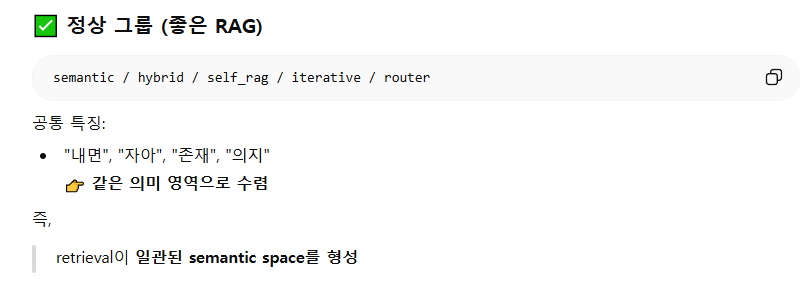
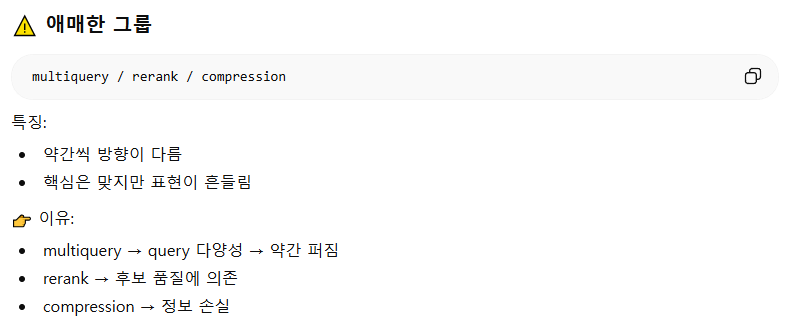